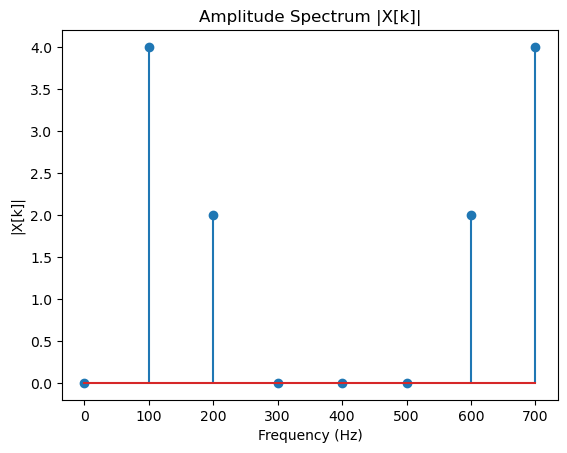

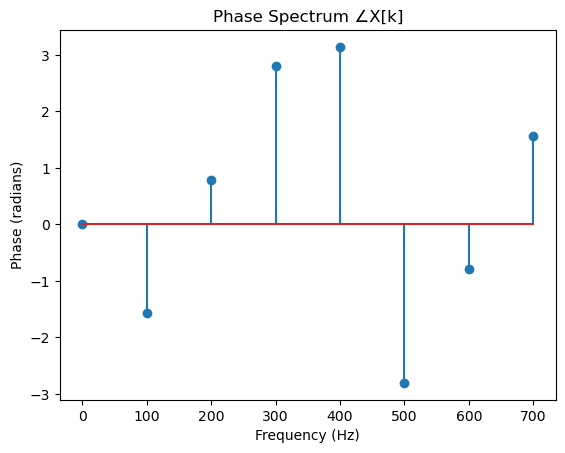

In [ ]:
# Import numerical and plotting libraries
import numpy as np
import matplotlib.pyplot as plt

# User-defined FFT (Cooley-Tukey, radix-2 recursive)
def user_fft(x):
    x = np.asarray(x, dtype=complex)
    N = x.shape[0]

    # Base case
    if N == 1:
        return x

    # If N is odd, use direct DFT as fallback
    if N % 2 != 0:
        n = np.arange(N)
        k = n.reshape((N, 1))
        W = np.exp(-2j * np.pi * k * n / N)
        return W @ x

    # Divide-and-conquer for even-length sequences
    X_even = user_fft(x[::2])
    X_odd = user_fft(x[1::2])
    factor = np.exp(-2j * np.pi * np.arange(N) / N)

    return np.concatenate([
        X_even + factor[:N // 2] * X_odd,
        X_even + factor[N // 2:] * X_odd
    ])

# Define sampling parameters and create test signal
fs = 800
N = 8
n = np.arange(N)
x = np.sin(2*np.pi*100*n/fs) + 0.5*np.sin(2*np.pi*200*n/fs + 3*np.pi/4)

# Compute user-defined FFT and map bins to frequency in Hz
X = user_fft(x)
k = np.arange(N)
freq = k * fs / N

# Plot magnitude spectrum
plt.stem(freq, np.abs(X))
plt.title('Amplitude Spectrum |X[k]| (User FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('|X[k]|')
plt.show()

# Plot phase spectrum
plt.stem(freq, np.angle(X))
plt.title('Phase Spectrum ∠X[k] (User FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (radians)')
plt.show()

# Optional check against NumPy FFT
X_np = np.fft.fft(x, N)
print('Matches NumPy FFT:', np.allclose(X, X_np))